In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 필요에 따라 추후 WER도 계산하는거 구현해서 metric으로 사용해도 좋을듯

In [3]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [4]:
import editdistance


# def exprate_k(preds, targets, k=0, eos_idx=1):

#     # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

#     # preds: (B, T-1)
#     # targets: (B, T-1)

#     assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

#     cnt = 0
#     for pred_seq, tgt_seq in zip(preds, targets):

#         pred = pred_seq.tolist()
#         tgt = tgt_seq.tolist()

#         if eos_idx in pred:
#             pred = pred[:pred.index(eos_idx)]

#         if eos_idx in tgt:
#             tgt = tgt[:tgt.index(eos_idx)]

#         diff = editdistance.eval(pred, tgt)

#         if diff<=k:
#             cnt += 1

#     return cnt / preds.shape[0]


def exprate_k_revised(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    ignore_count = 0

    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        diff_lim = len(tgt)    # 거리오차는 target 길이보다 커질 수 없음

        if diff_lim <= k:    # 만약 거리오차 최댓값보다 같거나 더 큰 오차를 허용한다면 해당경우 무시 (무시하지 않을경우 의미 왜곡 발생하여 메트릭으로서의 기능상실)
            ignore_count += 1
            continue

        if diff<=k:
            cnt += 1

    if ignore_count==preds.shape[0]:
        is_ignore_all_batch = True
    else:
        is_ignore_all_batch = False

    return cnt / preds.shape[0], is_ignore_all_batch    # 만약 모든 배치에서 expr@k 계산하려고 할때 오차 최댓값이 k 이상이 되어 해당경우는 expr@k 메트릭으로 평가하면 메트릭으로서의 의미왜곡이 생길 수 있어 패스해야하는지 체크하는 인자를 함께 반한 (최종적으로 평균계산할때 이렇게 패스된 부분 고려해서 의미왜곡없이 평균 취해주기 위함)


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1 (revised)", "expr@2 (revised)", "expr@3 (revised)", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [7]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [8]:
import os, json
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))
optimizer_name = input("optimizer name (AdamW, adadelta, ...): ")

CFG = {
  "img_size": (128,768),
  "pad_idx": 112,
  "sos_idx": 0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 113,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": optimizer_name,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = "WAPTransformer (without augmentation) - 128x768 resize"
scheduler_name = input("scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): ")
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"


CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

epoch: 100
patience: 100
batch size: 16
optimizer name (AdamW, adadelta, ...): adamw
scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): circularlrbeta
min_lr: 5e-4
max_lr: 5e-4


In [9]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/WAPTransformer (without augmentation) - 128x768 resize_epoch100_patience_100_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [10]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [11]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [12]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

## Augmentation

In [13]:
import torch
from torchvision import transforms
import numpy as np
import random
import cv2
from PIL import Image, ImageFilter, ImageOps

# # --- SimCLR 스타일 GaussianBlur (이미지 크기 기반으로 커널 자동 설정) ---
# class GaussianBlur(object):
#     def __init__(self, p, height, width, min_sigma=0.1, max_sigma=1.5, alpha=0.02):
#         self.p = p
#         self.H = height
#         self.W = width
#         self.min_sigma = min_sigma
#         self.max_sigma = max_sigma
#         self.alpha = alpha

#     def __call__(self, img):
#         prob = random.random()
#         if prob < self.p:
#             sigma = random.uniform(self.min_sigma, self.max_sigma)
#             ksize = int(2 * np.ceil(3 * self.alpha * min(self.H, self.W)) + 1)
#             if ksize % 2 == 0:
#                 ksize += 1
#             np_img = np.array(img)
#             np_img = cv2.GaussianBlur(np_img, (ksize, ksize), sigma)
#             img = Image.fromarray(np.uint8(np_img))
#         return img


# # --- 작은 크기의 Cutout/Erasing (수식 일부만 가려지지 않게 아주 약하게) ---
# class SmallRandomErasing(object):
#     def __init__(self, p=0.1, max_size_ratio=0.02):
#         self.p = p
#         self.max_size_ratio = max_size_ratio

#     def __call__(self, img):
#         if random.random() > self.p:
#             return img
#         w, h = img.size
#         erase_w = int(w * self.max_size_ratio)
#         erase_h = int(h * self.max_size_ratio)
#         x = random.randint(0, w - erase_w)
#         y = random.randint(0, h - erase_h)
#         np_img = np.array(img)
#         np_img[y:y+erase_h, x:x+erase_w] = 255  # 흰색으로 지우기
#         return Image.fromarray(np.uint8(np_img))



# train_tf = transforms.Compose([
#     transforms.Resize(CFG["img_size"]),
#     transforms.RandomApply([
#         transforms.RandomAffine(
#             degrees=3,              # 회전 ±3°
#             translate=(0.02, 0.02), # 위치 ±2%
#             scale=(0.97, 1.03),     # 크기 ±3%
#             shear=(-2, 2),          # 기울기 ±2°
#             fill=255                # 배경 흰색 채우기
#         )
#     ], p=0.5),

#     GaussianBlur(p=0.5, height=128, width=768, min_sigma=0.1, max_sigma=1.5),

#     transforms.RandomApply([
#         transforms.Lambda(lambda img: img.filter(ImageFilter.MedianFilter(size=3)))
#     ], p=0.5),

#     transforms.RandomApply([
#         SmallRandomErasing(p=0.5, max_size_ratio=0.015)
#     ], p=0.5),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5], std=[0.5]),
# ])




test_tf = transforms.Compose([
    transforms.Resize(CFG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


In [14]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [15]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

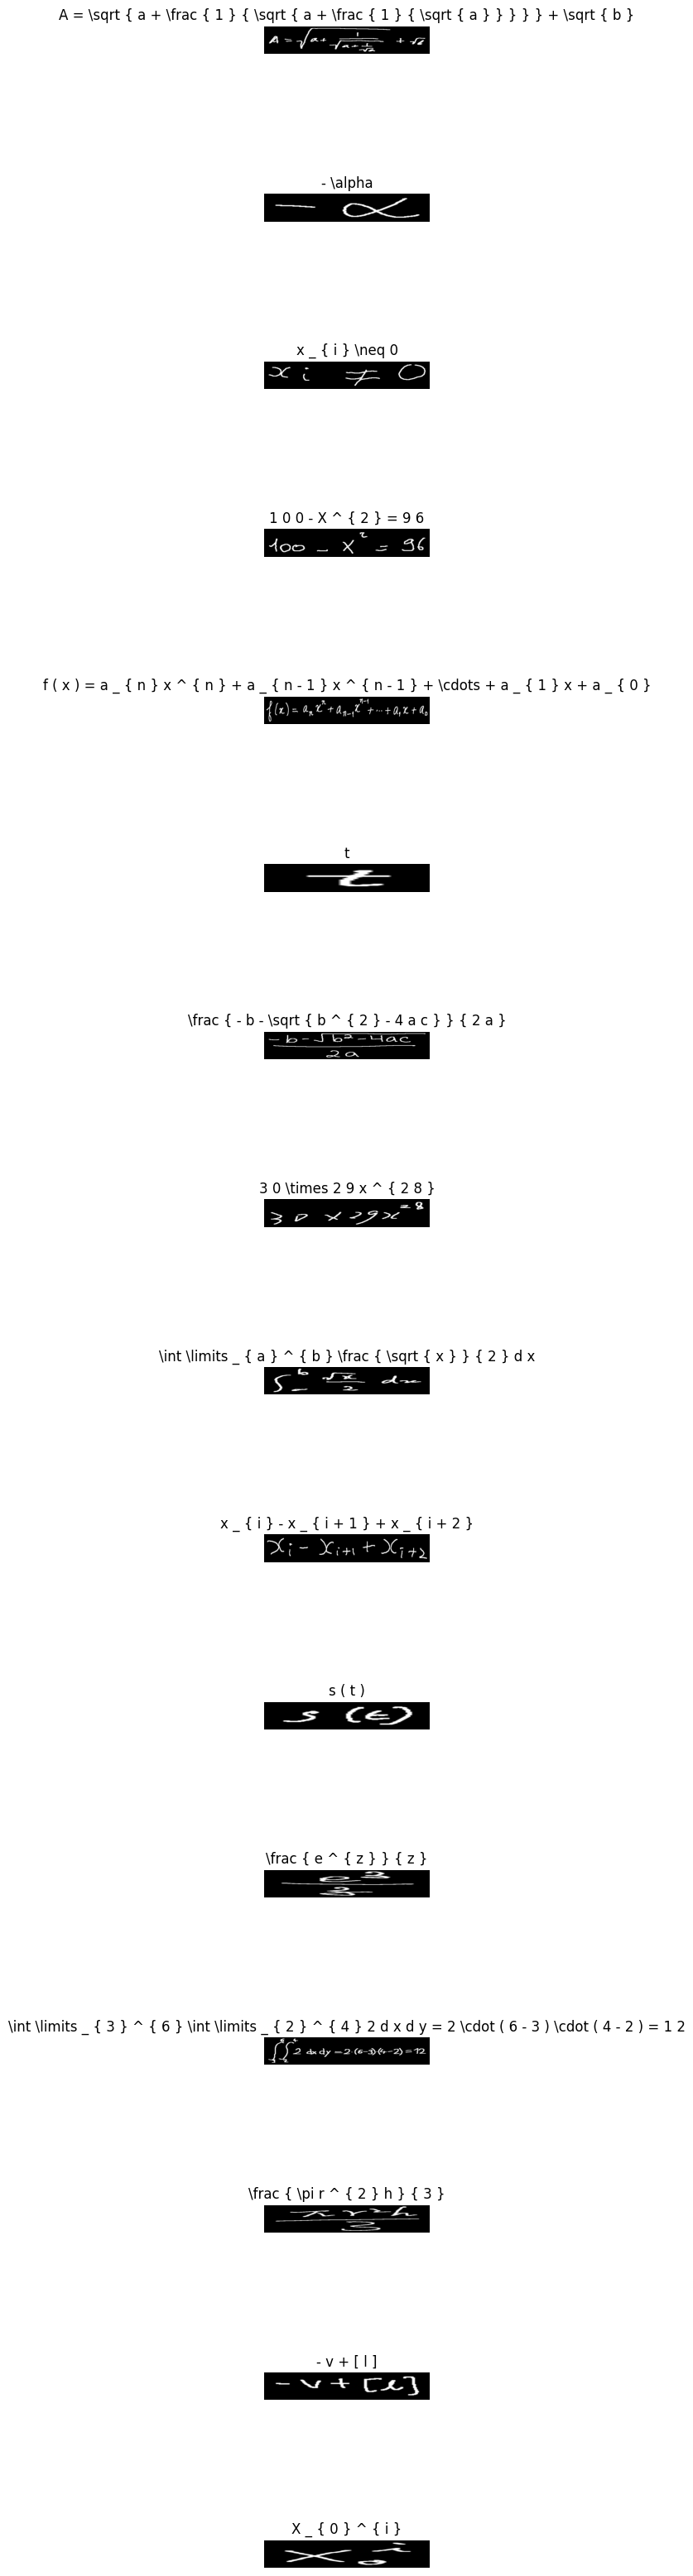

In [16]:
batch_size = CFG["training"]["batch_size"]


# train valid split
full_dataset = FormulaDataset(train_path, train_labels_path, transform=None, vocab=vocab)

train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size
train_idx, valid_idx = torch.utils.data.random_split(range(len(full_dataset)), [train_size, valid_size])

# 3. transform 다른 Dataset 두 개 만들기
trainset = torch.utils.data.Subset(
    FormulaDataset(train_path, train_labels_path, transform=test_tf, vocab=vocab),
    train_idx.indices
)

validset = torch.utils.data.Subset(
    FormulaDataset(train_path, train_labels_path, transform=test_tf, vocab=vocab),
    valid_idx.indices
)



# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], test_tf, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], test_tf, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], test_tf, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], test_tf, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], test_tf, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], test_tf, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, test_tf, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, test_tf, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=bs, figure_width=1, figure_height=bs, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

In [17]:
# WAPTransformer 모델을 위해 필요한 하이퍼파라미터 추가

WAPTransformer_params = {
    "input_dim": 1024,
    "d_model": 256,
    "nhead": 8,
    "num_encoder_layers": 3,
    "num_decoder_layers": 3,
    "dropout": 0.1
}


CFG["model"]["WAPTransformer"] = WAPTransformer_params

In [18]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/WAPTransformer (without augmentation) - 128x768 resize_epoch100_patience_100_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [19]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights


class DenseNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        densenet = densenet121(weights=None)    # 이번 프로젝트는 imageNet 데이터에 비교하면 수식글씨로, imageNet 가중치가 방해될 수도 있어 사전학습 가중치 없이 불러오는게 유리할수도 있음

        # First conv layer 수정: in_channels=1로 (우리 프로젝트에 맞춰 gpu 메모리 소모 줄이기 위해 그레이스케일로 변환)
        densenet.features.conv0 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove classification head
        features = list(densenet.features.children())

        # Use all layers except final norm+relu+avgpool
        self.backbone = nn.Sequential(*features[:-1])

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)                       # (B,1,128,768) -> (B,1024,4,24)
        B, D, _, _ = x.shape
        x = x.reshape(B, D, -1)                    # (B,1024,4*24)
        x = x.transpose(1,2)                       # (B,1024,96) -> (B,96,1024)
        return x


In [20]:
import torch
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)  # (L, D)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, L, D)

        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: (B, L, D)
        """
        x = x + self.pe[:, :x.size(1)]  # (B, L, D)
        return self.dropout(x)


class Encoder(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, src):
        """
        src: (B, L, input_dim)
        """
        src = self.input_proj(src)
        src = self.pos_encoder(src)  # (B, L, D)
        memory = self.transformer_encoder(src)  # (B, L, D)
        return memory


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dropout=dropout,
                                                   batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        """
        tgt: (B, L_tgt)
        memory: (B, L_src, D)
        """
        tgt = self.embedding(tgt)     # (B, L_tgt) -> (B, L_tgt, D)
        tgt = self.pos_encoder(tgt)

        output = self.transformer_decoder(tgt, memory, tgt_mask=tgt_mask, memory_mask=memory_mask,
                                          tgt_key_padding_mask=tgt_key_padding_mask,
                                          memory_key_padding_mask=memory_key_padding_mask)

        logits = self.fc_out(output)  # (B, L_tgt, D) -> (B, L_tgt, V)

        return logits


class WAPTransformer(nn.Module):
    def __init__(self, model_config=None):
        super().__init__()

        self.backbone = DenseNetEncoder()

        self.input_dim = model_config.get("WAPTransformer").get("input_dim", 1024)
        self.vocab_size = model_config.get("vocab_size", 113)
        self.d_model = model_config.get("WAPTransformer").get("d_model", 256)
        self.nhead = model_config.get("WAPTransformer").get("nhead", 8)
        self.num_encoder_layers = model_config.get("WAPTransformer").get("num_encoder_layers", 3)
        self.num_decoder_layers = model_config.get("WAPTransformer").get("num_decoder_layers", 3)
        self.dropout = model_config.get("WAPTransformer").get("dropout", 0.1)

        self.encoder = Encoder(self.input_dim, self.d_model, self.nhead, self.num_encoder_layers, self.dropout)
        self.decoder = Decoder(self.vocab_size, self.d_model, self.nhead, self.num_decoder_layers, self.dropout)


    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz, dtype=torch.bool), diagonal=1)  # float tensor
        return mask


    def forward(self, img, tgt):
        """
        img: (B, C, H, W)
        src: (B, L_src, input_dim)
        tgt: (B, L_tgt)
        """

        src = self.backbone(img)    # (B,96,1024)

        memory = self.encoder(src)  # (B,96,256)

        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        tgt_pad_mask = (tgt == CFG["pad_idx"])

        output = self.decoder(
            tgt, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask
        )

        return output

    # inference mode인 경우
    def greedy_decode(self, img, max_len=100):
        src = self.backbone(img)
        memory = self.encoder(src)

        ys = torch.full((img.size(0), 1), CFG["sos_idx"]).long().to(img.device)   # <sos>

        for _ in range(max_len):
            tgt_mask = self.generate_square_subsequent_mask(ys.size(1)).to(img.device)
            out = self.decoder(ys, memory, tgt_mask=tgt_mask)
            next_token = out[:, -1, :].argmax(dim=-1).unsqueeze(1)
            ys = torch.cat([ys, next_token], dim=1)
            if (next_token == CFG["eos_idx"]).all():
                break

        return ys



# Train

- 변경사항: scheduler 하이퍼파라미터 오버핏 방지되고 안정적으로 수렴하도록 학습하는 에포크랑 스텝 수 고려해서 재설정
    - PairedDataset에 맞도록 수정 및 optimizer.zero_grad()위치 등 자잘한 디테일도 수정

-  변경사항: early stop patience가 validation이 아닌 train 쪽에 있었는데, validation 쪽에서 patience 동작하도록 수정필요 + 편의상 patience에 가까워질때마다 로그 찍히도록 수정 + train 도중 keyboard interrupt 받아서 셀 스탑 되어도 log_dict, best_loss 반환하도록 try except finally 구문 이용해서 수정

In [21]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            num_ignore_for_expr1 = 0
            num_ignore_for_expr2 = 0
            num_ignore_for_expr3 = 0

            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels[:, :-1])      # eos 부분은 제외해서 입력: (B,T-1,V) -> (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                if ignore_flag_expr1==False:
                    total_expr_1 += float(expr_1)
                else:
                    expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr2==False:
                    total_expr_2 += float(expr_2)
                else:
                    expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr3==False:
                    total_expr_3 += float(expr_3)
                else:
                    expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                total_wer += float(wer)

                if ignore_flag_expr1:
                    num_ignore_for_expr1 += 1

                if ignore_flag_expr2:
                    num_ignore_for_expr2 += 1

                if ignore_flag_expr3:
                    num_ignore_for_expr3 += 1

                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
            avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
            avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
            # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            num_ignore_for_expr1 = 0
            num_ignore_for_expr2 = 0
            num_ignore_for_expr3 = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels[:, :-1])      # eos 부분은 제외해서 입력: (B,T-1,V) -> (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                if ignore_flag_expr1==False:
                    total_expr_1 += float(expr_1)
                else:
                    expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr2==False:
                    total_expr_2 += float(expr_2)
                else:
                    expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr3==False:
                    total_expr_3 += float(expr_3)
                else:
                    expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                total_wer += float(wer)

                if ignore_flag_expr1:
                    num_ignore_for_expr1 += 1

                if ignore_flag_expr2:
                    num_ignore_for_expr2 += 1

                if ignore_flag_expr3:
                    num_ignore_for_expr3 += 1

                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
            avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
            avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
            # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

# Scheduler

In [22]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [23]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [24]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [25]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [ ]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

In [ ]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = WAPTransformer(model_config=CFG["model"]).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/100: 100%|██████████| 442/442 [01:54<00:00,  3.87it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.09, lr=6e-5, wer=0.753]



[Train Epoch 1] Loss: 2.5894, Expr@0: 0.0001, Expr@1: 0.0040, Expr@2: 0.0158, Expr@3: 0.0337, WER: 1.3614


[Valid] Epoch 1/100: 100%|██████████| 1767/1767 [01:10<00:00, 25.03it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=1.69, wer=0.545]



[Valid Epoch 1] Loss: 2.3608, Expr@0: 0.0006, Expr@1: 0.0157, Expr@2: 0.0412, Expr@3: 0.0952, WER: 0.6714
Best model saved.



[Train] Epoch 2/100: 100%|██████████| 442/442 [01:53<00:00,  3.89it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=1.49, lr=7e-5, wer=0.57]


...


[Valid Epoch 99] Loss: 0.3461, Expr@0: 0.6933, Expr@1: 0.8294, Expr@2: 0.8821, Expr@3: 0.9147, WER: 0.0736
Early Stopping count: 12/100



[Train] Epoch 100/100: 100%|██████████| 442/442 [01:50<00:00,  3.99it/s, expr0=1, expr1=1, expr2=0.909, expr3=0.818, loss=0.000167, lr=5.22e-7, wer=0]



[Train Epoch 100] Loss: 0.0022, Expr@0: 0.9907, Expr@1: 0.9454, Expr@2: 0.9127, Expr@3: 0.8613, WER: 0.0012


[Valid] Epoch 100/100: 100%|██████████| 1767/1767 [01:01<00:00, 28.79it/s, expr0=1, expr1=1, expr2=1, expr3=1, loss=1.12e-6, wer=0]



[Valid Epoch 100] Loss: 0.3462, Expr@0: 0.6904, Expr@1: 0.8270, Expr@2: 0.8821, Expr@3: 0.9140, WER: 0.0746
Early Stopping count: 13/100



In [ ]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/WAPTransformer (without augmentation) - 128x768 resize_epoch100_patience_100_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/train_log.json


In [ ]:
!pip install torchinfo -q
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                                                 Param #
WAPTransformer                                                         --
├─DenseNetEncoder: 1-1                                                 --
│    └─Sequential: 2-1                                                 --
│    │    └─Conv2d: 3-1                                                3,136
│    │    └─BatchNorm2d: 3-2                                           128
│    │    └─ReLU: 3-3                                                  --
│    │    └─MaxPool2d: 3-4                                             --
│    │    └─_DenseBlock: 3-5                                           335,040
│    │    └─_Transition: 3-6                                           33,280
│    │    └─_DenseBlock: 3-7                                           919,680
│    │    └─_Transition: 3-8                                           132,096
│    │    └─_DenseBlock: 3-9                                           2,837,760
│  

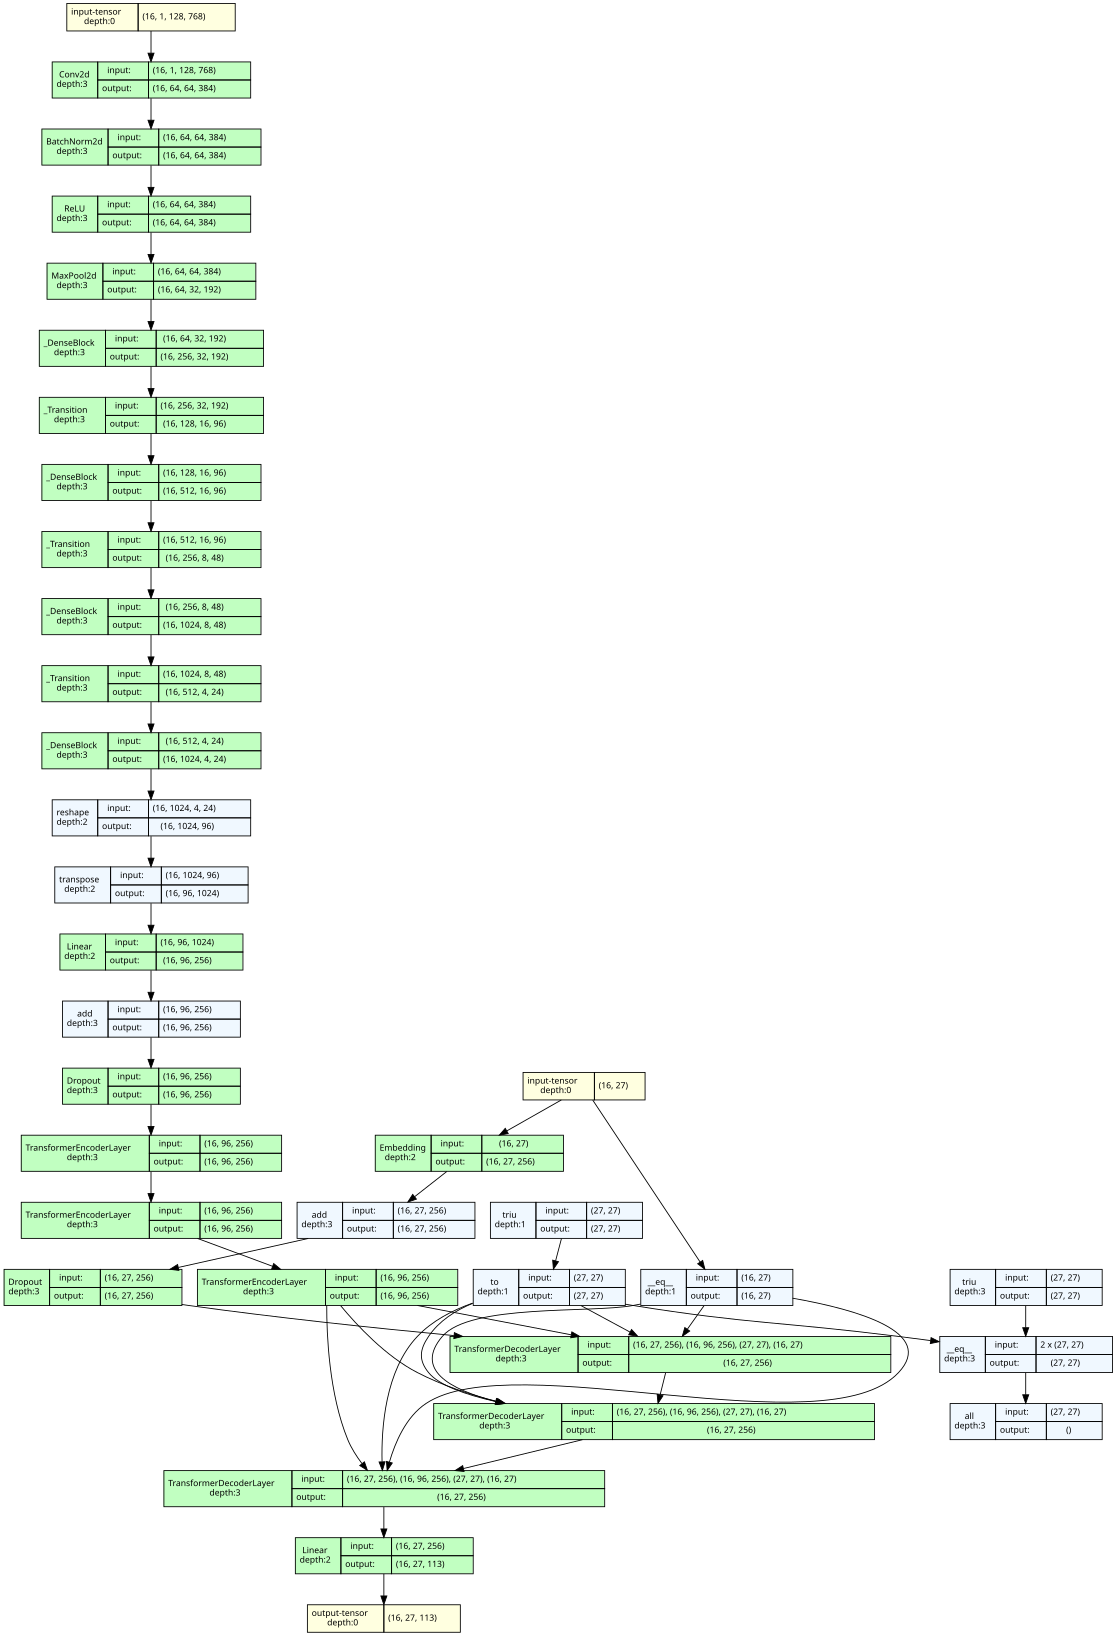

In [ ]:
!pip install torchview -q
from torchview import draw_graph

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

graph = draw_graph(model, input_data=(images, labels))
display(graph.visual_graph)

In [ ]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

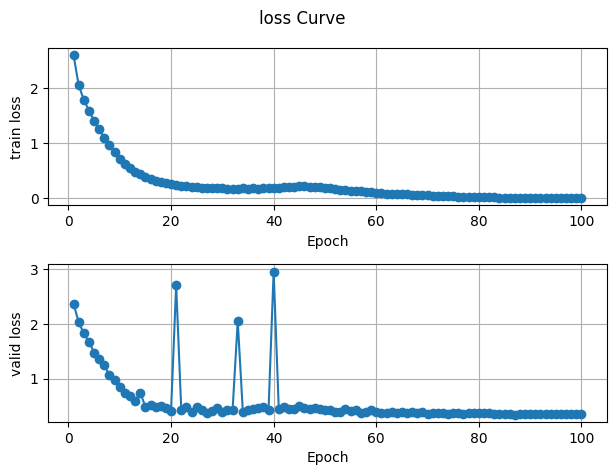

In [ ]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

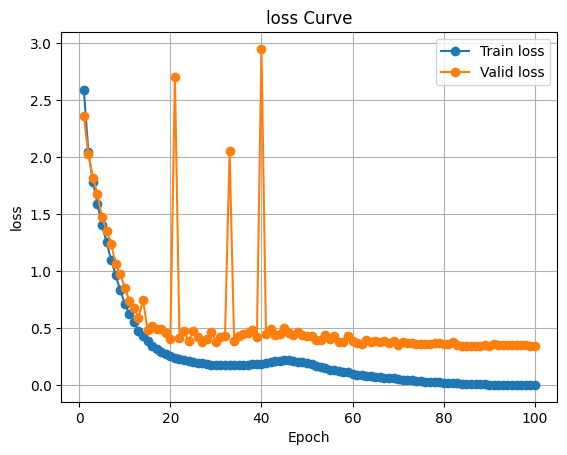

In [ ]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

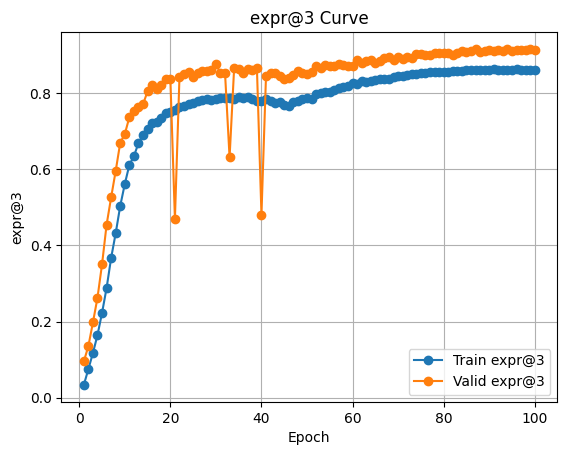

In [ ]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

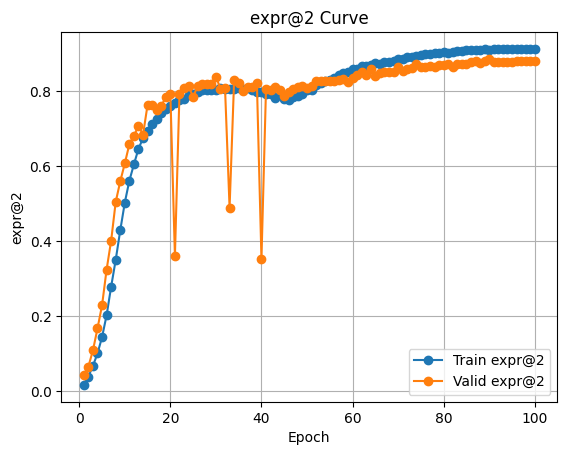

In [ ]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

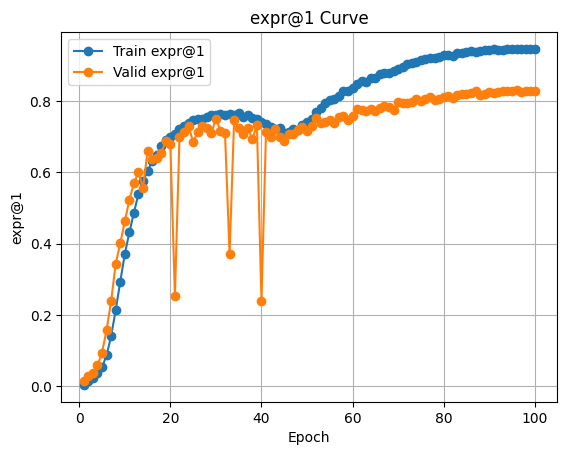

In [ ]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

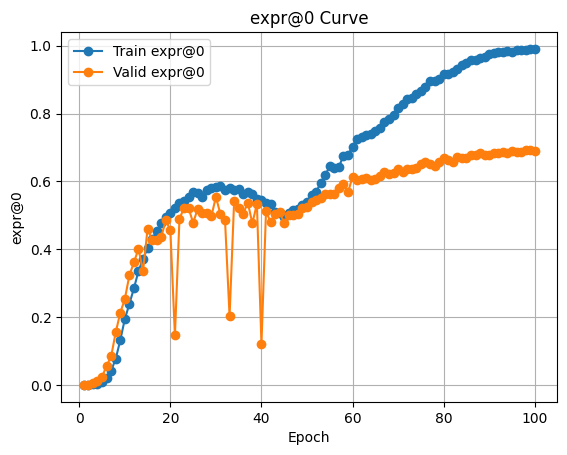

In [ ]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

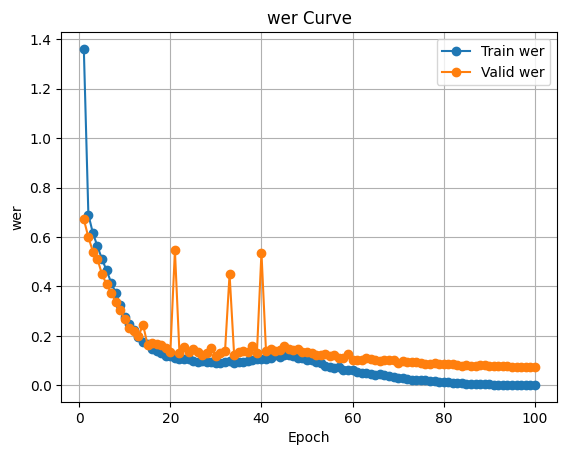

In [ ]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

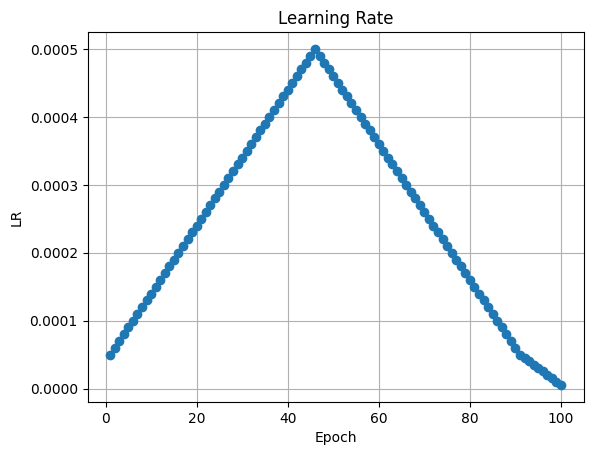

In [ ]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    num_ignore_for_expr1 = 0
    num_ignore_for_expr2 = 0
    num_ignore_for_expr3 = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels[:, :-1])      # eos 부분은 제외해서 입력: (B,T-1,V) -> (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
        expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
        expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
        expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
        wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

        total_loss += float(loss.item())
        total_expr_0 += float(expr_0)
        if ignore_flag_expr1==False:
            total_expr_1 += float(expr_1)
        else:
            expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        if ignore_flag_expr2==False:
            total_expr_2 += float(expr_2)
        else:
            expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        if ignore_flag_expr3==False:
            total_expr_3 += float(expr_3)
        else:
            expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        total_wer += float(wer)

        if ignore_flag_expr1:
            num_ignore_for_expr1 += 1

        if ignore_flag_expr2:
            num_ignore_for_expr2 += 1

        if ignore_flag_expr3:
            num_ignore_for_expr3 += 1

        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
    avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
    avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
    # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 테스트데이터셋의 크기를 고려할 때 해당경우 없다고 가정해서 처리하는 부분을 따로 마련해주지 않았음
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [27]:
# best_model.pth 가져오기

model = WAPTransformer(model_config=CFG["model"]).to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1 (revised)": [],
            "expr@2 (revised)": [],
            "expr@3 (revised)": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    print(f"Loss: {loss:.4f}, Expr@0: {expr0:.4f}, Expr@1: {expr1:.4f}, Expr@2: {expr2:.4f}, Expr@3: {expr3:.4f}, WER: {wer:.4f}")

    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1 (revised)"].append(expr1)
    val_dict["expr@2 (revised)"].append(expr2)
    val_dict["expr@3 (revised)"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [00:33<00:00, 29.33it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.08, lr=5.11e-7, wer=0.74]


Loss: 1.2547, Expr@0: 0.2241, Expr@1: 0.4193, Expr@2: 0.5277, Expr@3: 0.5935, WER: 0.2234
CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [00:38<00:00, 29.43it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.91, lr=5.11e-7, wer=0.69]


Loss: 1.3350, Expr@0: 0.1779, Expr@1: 0.3470, Expr@2: 0.4799, Expr@3: 0.5494, WER: 0.2358
CROHME_2019


...

Loss: 6.2348, Expr@0: 0.0000, Expr@1: 0.0008, Expr@2: 0.0059, Expr@3: 0.0240, WER: 0.7737
IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [00:32<00:00, 29.43it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=7.99, lr=5.11e-7, wer=0.939]


Loss: 9.3402, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0000, Expr@3: 0.0000, WER: 0.8346
IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [00:32<00:00, 29.31it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=6.43, lr=5.11e-7, wer=0.848]


Loss: 9.2662, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0000, Expr@3: 0.0000, WER: 0.7816


# Prediction 샘플 시각화

In [46]:
# 시각화를 위한 테스트로더 별도 구성 (shuffle=True로 해서 다양한 케이스 확인할 수 있도록)

# test - CROHME

sample_crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

sample_crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

sample_crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME

sample_cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

sample_cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

sample_cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX

sample_im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

sample_im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=True, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

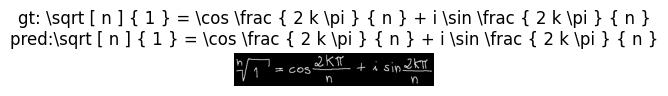

In [28]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

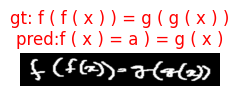

In [38]:
import numpy as np

batch = next(iter(sample_crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

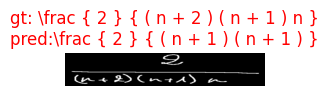

In [39]:
import numpy as np

batch = next(iter(sample_crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

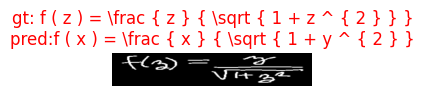

In [40]:
import numpy as np

batch = next(iter(sample_crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

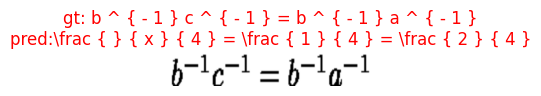

In [41]:
import numpy as np

batch = next(iter(sample_cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

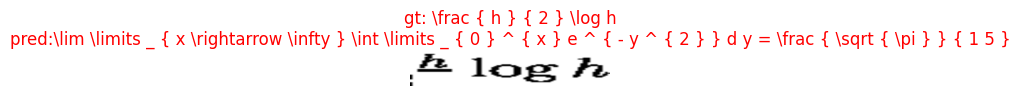

In [42]:
import numpy as np

batch = next(iter(sample_cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

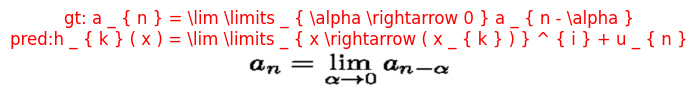

In [43]:
import numpy as np

batch = next(iter(sample_cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

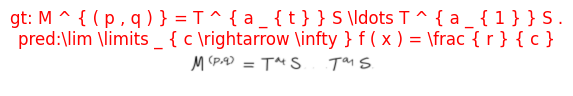

In [47]:
import numpy as np

batch = next(iter(sample_im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

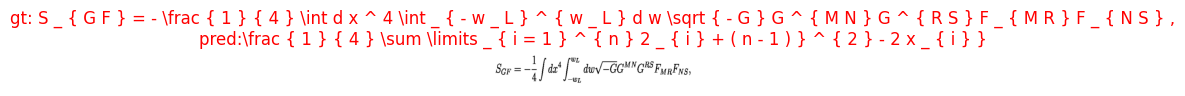

In [48]:
import numpy as np

batch = next(iter(sample_im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.greedy_decode(images)[:, 1:]
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)